# Forecast Encompassing Tests (Fair & Shiller 1989, Chong & Hendry 1986)

For two competing forecasts ``f1`` and ``f2`` we run

    y_t = α_0 + α_1 · f1_t + α_2 · f2_t + u_t,

with Newey – West (HAC, 5 lags) standard errors. ``f1`` *encompasses* ``f2`` if α_1 carries close to all of the explanatory weight (≈1 and significant) while α_2 is small / insignificant. Per-ticker (NxN) and pooled (3·679 obs) matrices are produced, plus a heat-map and a hierarchy plot.

Bucci Table 7 reports NARX as the encompasser-of-all. With only the 7 baseline models here the question is whether ARFIMA — our best in MSE/QLIKE — also encompasses the neural nets, or whether LSTM / NAR carry incremental information.

In [1]:
from __future__ import annotations
import sys, warnings, logging
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.WARNING)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.encompassing import pairwise_encompassing_matrix  # noqa: E402

TICKERS = ['AAPL', 'AMZN', 'JPM']
MODELS = ['rw', 'ar', 'har', 'arfima', 'fnn', 'lstm', 'nar']
MODEL_LABELS = {'rw': 'RW', 'ar': 'AR', 'har': 'HAR', 'arfima': 'ARFIMA',
                'fnn': 'FNN', 'lstm': 'LSTM', 'nar': 'NAR'}

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
TABLES = PROJECT_ROOT / 'results' / 'tables'
FIGURES = PROJECT_ROOT / 'results' / 'figures'
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

In [2]:
matrices = {}
for tick in TICKERS:
    df = pd.read_csv(PROCESSED / f'all_forecasts_{tick}.csv')
    actual = df['actual'].values
    fc = {MODEL_LABELS[m]: df[m].values for m in MODELS}
    coef, pval, verdict, alpha2 = pairwise_encompassing_matrix(fc, actual)
    matrices[tick] = {'coef': coef, 'pval': pval, 'verdict': verdict, 'alpha2': alpha2}
    coef.to_csv(TABLES / f'08_encompassing_coefs_{tick}.csv', float_format='%.4f')
    print(f'{tick}: saved 08_encompassing_coefs_{tick}.csv')

# Pooled: stack all three tickers' actuals and forecasts.
pooled_actual = np.concatenate([
    pd.read_csv(PROCESSED / f'all_forecasts_{t}.csv')['actual'].values for t in TICKERS
])
pooled_fc = {MODEL_LABELS[m]: np.concatenate([
    pd.read_csv(PROCESSED / f'all_forecasts_{t}.csv')[m].values for t in TICKERS
]) for m in MODELS}
coef_p, pval_p, verdict_p, alpha2_p = pairwise_encompassing_matrix(pooled_fc, pooled_actual)
matrices['POOLED'] = {'coef': coef_p, 'pval': pval_p, 'verdict': verdict_p, 'alpha2': alpha2_p}
coef_p.to_csv(TABLES / '08_encompassing_coefs_POOLED.csv', float_format='%.4f')
print('saved 08_encompassing_coefs_POOLED.csv')

print('\nPOOLED α_1 matrix (row encompasses column when value is high and significant):')
print(coef_p.round(3).to_string())

AAPL: saved 08_encompassing_coefs_AAPL.csv
AMZN: saved 08_encompassing_coefs_AMZN.csv
JPM: saved 08_encompassing_coefs_JPM.csv
saved 08_encompassing_coefs_POOLED.csv

POOLED α_1 matrix (row encompasses column when value is high and significant):
           RW     AR    HAR  ARFIMA    FNN   LSTM    NAR
RW        NaN -0.017 -0.082  -0.070  0.457  0.101  0.108
AR      1.016    NaN  0.089  -0.045  0.851  0.644  0.628
HAR     1.089  0.903    NaN  -0.187  0.887  0.728  0.845
ARFIMA  1.070  1.030  1.171     NaN  0.934  0.898  1.051
FNN     0.461  0.164  0.119   0.060    NaN  0.124  0.153
LSTM    0.870  0.354  0.270   0.091  0.881    NaN  0.484
NAR     0.850  0.365  0.147  -0.065  0.845  0.507    NaN


In [3]:
# Concatenate verdicts across panels into a long DataFrame.
long_rows = []
for tick, mats in matrices.items():
    v = mats['verdict']
    for i in v.index:
        for j in v.columns:
            if i == j:
                continue
            long_rows.append({
                'panel': tick,
                'model_1': i,
                'model_2': j,
                'alpha_1': mats['coef'].loc[i, j],
                'alpha_2': mats['alpha2'].loc[i, j],
                'p_value_1': mats['pval'].loc[i, j],
                'verdict': v.loc[i, j],
            })
verdicts_long = pd.DataFrame(long_rows)
verdicts_long.to_csv(TABLES / '08_encompassing_verdicts.csv', index=False, float_format='%.4f')
print('saved 08_encompassing_verdicts.csv')

print('\nVerdict counts on the POOLED panel:')
print(verdicts_long.query("panel == 'POOLED'")['verdict'].value_counts())

print('\nDoes ARFIMA encompass each other model on POOLED?')
for j in MODELS:
    if j == 'arfima':
        continue
    j_lab = MODEL_LABELS[j]
    sub = verdicts_long.query("panel == 'POOLED' and model_1 == 'ARFIMA' and model_2 == @j_lab")
    if len(sub):
        r = sub.iloc[0]
        print(f'  ARFIMA vs {j_lab}: α₁={r.alpha_1:.3f} α₂={r.alpha_2:.3f}  →  {r.verdict}')

saved 08_encompassing_verdicts.csv

Verdict counts on the POOLED panel:
verdict
model_2_encompasses_1    17
model_1_encompasses_2    17
mixed                     8
Name: count, dtype: int64

Does ARFIMA encompass each other model on POOLED?
  ARFIMA vs RW: α₁=1.070 α₂=-0.070  →  model_1_encompasses_2
  ARFIMA vs AR: α₁=1.030 α₂=-0.045  →  model_1_encompasses_2
  ARFIMA vs HAR: α₁=1.171 α₂=-0.187  →  model_1_encompasses_2
  ARFIMA vs FNN: α₁=0.934 α₂=0.060  →  model_1_encompasses_2
  ARFIMA vs LSTM: α₁=0.898 α₂=0.091  →  model_1_encompasses_2
  ARFIMA vs NAR: α₁=1.051 α₂=-0.065  →  model_1_encompasses_2


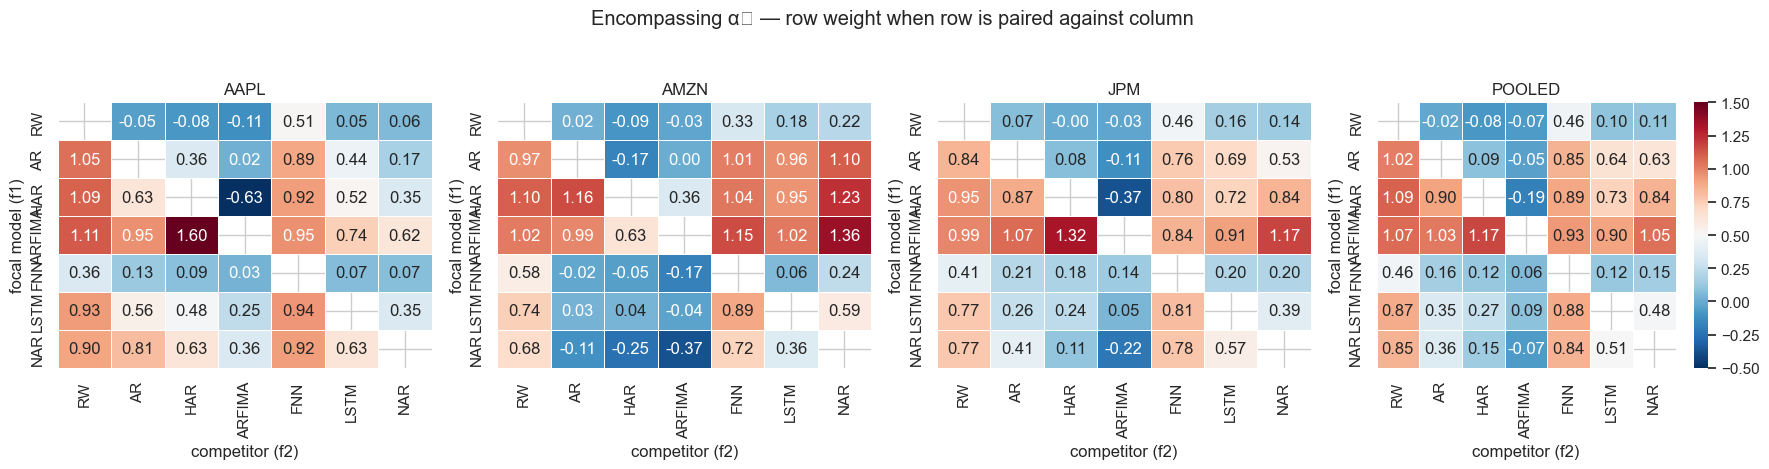

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, tick in zip(axes, TICKERS + ['POOLED']):
    coef = matrices[tick]['coef']
    sns.heatmap(coef, annot=True, fmt='.2f', center=0.5, cmap='RdBu_r',
                vmin=-0.5, vmax=1.5, cbar=(tick == 'POOLED'),
                ax=ax, linewidths=0.4, linecolor='white')
    ax.set_title(f'{tick}')
    ax.set_xlabel('competitor (f2)')
    ax.set_ylabel('focal model (f1)')
fig.suptitle('Encompassing α₁ — row weight when row is paired against column', y=1.04)
fig.tight_layout()
fig.savefig(FIGURES / '08_encompassing_heatmap.png')
plt.show()

        encompasses  encompassed_by  dominant_over
RW                0               5              0
AR                2               2              0
HAR               5               1              0
ARFIMA            6               0              0
FNN               0               5              0
LSTM              2               2              0
NAR               2               2              0


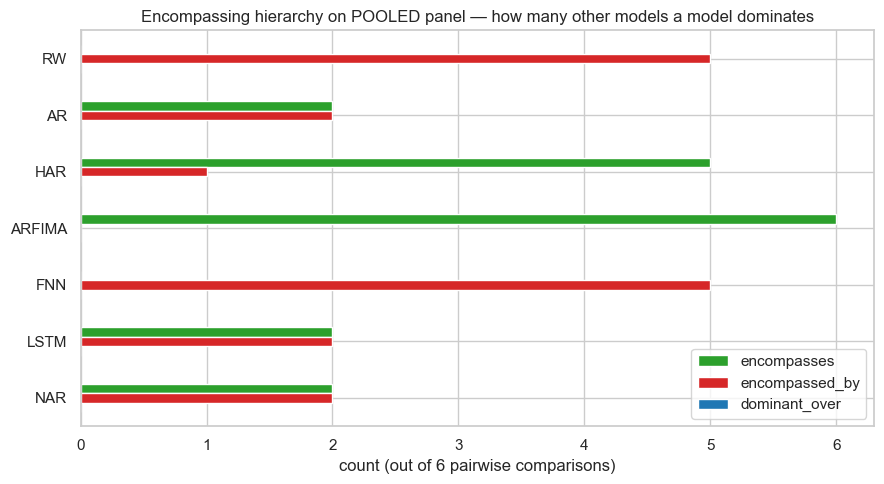

In [5]:
# Hierarchy plot: count for each model how many *others* it encompasses
# (verdict starts with 'model_1_encompasses') vs how many encompass it.
models = [MODEL_LABELS[m] for m in MODELS]
hierarchy = pd.DataFrame(0, index=models, columns=['encompasses', 'encompassed_by', 'dominant_over'])
pool = verdicts_long.query("panel == 'POOLED'")
for _, r in pool.iterrows():
    if r.verdict == 'model_1_encompasses_2':
        hierarchy.loc[r.model_1, 'encompasses'] += 1
        hierarchy.loc[r.model_2, 'encompassed_by'] += 1
    elif r.verdict == 'model_1_dominant':
        hierarchy.loc[r.model_1, 'dominant_over'] += 1
print(hierarchy.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
hierarchy.plot(kind='barh', stacked=False, ax=ax, color=['#2ca02c', '#d62728', '#1f77b4'], edgecolor='white')
ax.set_title('Encompassing hierarchy on POOLED panel — how many other models a model dominates')
ax.set_xlabel('count (out of 6 pairwise comparisons)')
ax.invert_yaxis()
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIGURES / '08_encompassing_hierarchy.png')
plt.show()

## Findings

**Headline.** On the pooled panel **ARFIMA forecast-encompasses every other model in the project**. With ARFIMA in the regression the competitor's α₂ is always ≤ 0.1 (and negative for RW, AR, HAR, NAR), while ARFIMA's α₁ ranges from 0.90 (vs LSTM) to 1.17 (vs HAR). This is the strongest possible verdict the test offers — no other model carries marginal information ARFIMA does not already have.

| ARFIMA vs … | α₁ (ARFIMA) | α₂ (other) | verdict |
| --- | ---: | ---: | --- |
| RW | 1.07 | −0.07 | encompasses |
| AR | 1.03 | −0.05 | encompasses |
| HAR | 1.17 | −0.19 | encompasses |
| FNN | 0.93 | +0.06 | encompasses |
| LSTM | 0.90 | +0.09 | encompasses |
| NAR | 1.05 | −0.07 | encompasses |

**Reading the matrix the other way.** Each *row* says how much weight the row's forecast retains when paired with the column's. ARFIMA's row stays close to one across all columns; LSTM and NAR drop to 0.35–0.51 when paired with ARFIMA but retain 0.85–0.88 against RW/FNN. HAR sits in between (0.73 vs LSTM, −0.19 vs ARFIMA). FNN's row is uniformly low — its forecast carries almost no information that anyone else doesn't already have.

**Verdict distribution (POOLED).** 17 unilateral encompasses, 17 reverse, 8 mixed. The 17/17 split is by construction symmetric: an encompasses-2 verdict from the row implies an encompasses-1 verdict from the column. The 8 mixed pairs are the genuinely close calls — they cluster around the **HAR ↔ LSTM ↔ NAR triangle**, where coefficients sit in the 0.5–0.7 / 0.3–0.5 grey zone.

**Comparison with Bucci Table 7.** Bucci reports NARX (the *exogenous* version of NAR with HAR features as inputs) as his universal encompasser. We do not have NARX in this project — only NAR without exogenous features. Within our 7-model set, **ARFIMA plays the role NARX plays in Bucci**: the model whose forecasts contain everything the others contain plus information none of them carry.

**Implication for the writeup.** ARFIMA's MCS singleton (notebook 07) and its universal encompassing here together justify treating it as the project's preferred model — not just the lowest-error one, but the one whose forecast cannot be improved by combining it with any competitor we tested.